In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/PaddleDet-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/My Drive/PaddleDet-Models


In [2]:
!python --version

Python 3.12.13


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/train/images")
count_images("datasets/sispanseg/valid/images")

Total images: 200
Total images: 56


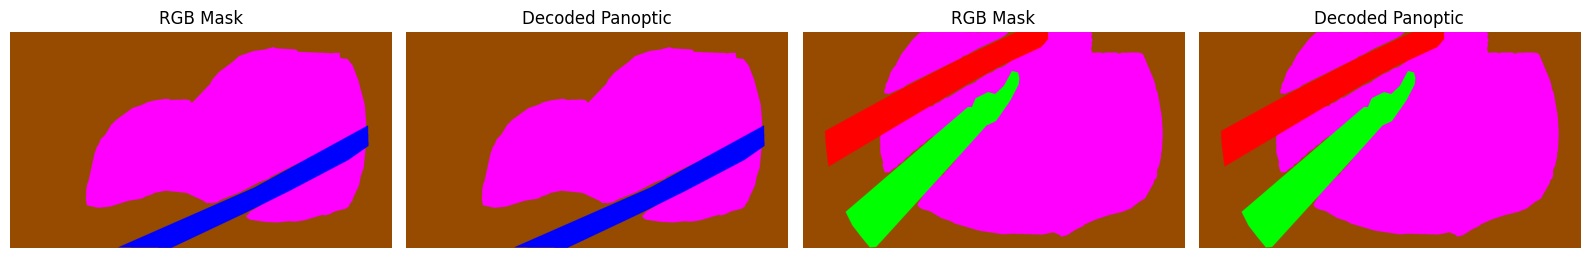

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# PATHS
# -------------------------
RGB_DIR = "datasets/sispanseg/train/rgbmasks"
MASK_DIR = "datasets/sispanseg/train/masks"

# -------------------------
# DEBUG COLORS (RGB)
# -------------------------
COLOR_Uterus = (255, 0, 255)            # Magenta - Suction
COLOR_BG = (150, 75, 0)                 # Brown
COLOR_Grasper_1 = (255, 0, 0)           # Red - Grasper
COLOR_Grasper_2 = (139, 0, 139)         # Purple
COLOR_Harmonic_ACE = (0, 255, 0)        # Green - Harmonic_Ace
COLOR_Myoma_Screw = (0, 0, 255)         # Blue - Myoma_Screw
COLOR_Needle_Holder_1 = (255, 255, 0)   # Yellow - Needle_Holder
COLOR_Needle_Holder_2 = (255, 174, 66)  # Orange Yellow
COLOR_Trocer = (0, 255, 255)            # Cyan - Trocar

Uterus = np.array(COLOR_Uterus)
BG = np.array(COLOR_BG)
Grasper_1 = np.array(COLOR_Grasper_1)
Grasper_2 = np.array(COLOR_Grasper_2)
Harmonic_ACE = np.array(COLOR_Harmonic_ACE)
Myoma_Screw = np.array(COLOR_Myoma_Screw)
Needle_Holder_1 = np.array(COLOR_Needle_Holder_1)
Needle_Holder_2 = np.array(COLOR_Needle_Holder_2)
Trocer = np.array(COLOR_Trocer)

# -------------------------
# LOAD FILES
# -------------------------
files = [f for f in os.listdir(RGB_DIR) if f.endswith(".png")]
samples = random.sample(files, 2)

# -------------------------
# FUNCTION: decode panoptic → RGB
# -------------------------
def decode_panoptic(mask):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    class_id = mask // 1000
    instance_id = mask % 1000

    # Grasper (class 1)
    Grasper1 = (class_id == 1) & (instance_id == 1)
    Grasper2 = (class_id == 1) & (instance_id == 2)

    out[Grasper1] = Grasper_1
    out[Grasper2] = Grasper_2

    # Harmonic (class 2)
    Harmonic = (class_id == 2)
    out[Harmonic] = Harmonic_ACE

    # Myoma Screw (class 3)
    Myoma = (class_id == 3)
    out[Myoma] = Myoma_Screw

    # Needle Holder (class 4)
    NeedleHolder1 = (class_id == 4) & (instance_id == 1)
    NeedleHolder2 = (class_id == 4) & (instance_id == 2)

    out[NeedleHolder1] = Needle_Holder_1
    out[NeedleHolder2] = Needle_Holder_2

    # Trocer (class 5)
    trocer = (class_id == 5)
    out[trocer] = Trocer

    # Uterus (class 6)
    uterus = (class_id == 6)
    out[uterus] = Uterus

    # Bg (class 7)
    Bg = (class_id == 7)
    out[Bg] = BG

    return out

# -------------------------
# PLOT
# -------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, fname in enumerate(samples):
    rgb_path = os.path.join(RGB_DIR, fname)
    mask_path = os.path.join(MASK_DIR, fname)

    rgb = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
    panoptic = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    decoded = decode_panoptic(panoptic)

    axes[i*2].imshow(rgb)
    axes[i*2].set_title(f"RGB Mask")
    axes[i*2].axis("off")

    axes[i*2+1].imshow(decoded)
    axes[i*2+1].set_title(f"Decoded Panoptic")
    axes[i*2+1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def convert_to_semantic(src_dir, dest_dir):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    files = [f for f in os.listdir(src_dir) if f.endswith(".png")]
    print(f"Converting {len(files)} masks from {src_dir}...")

    for fname in tqdm(files):
        mask_path = os.path.join(src_dir, fname)
        # Load the panoptic mask (class * 1000 + instance)
        panoptic = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        # Get the class IDs
        class_id = panoptic // 1000

        # Initialize output grayscale mask (background/void = 255)
        semantic = np.full(panoptic.shape, 255, dtype=np.uint8)

        # 1. Map all THING classes to 0
        semantic[(class_id >= 1) & (class_id <= 5)] = 0

        # 2. Map STUFF classes to contiguous IDs starting from 1
        # Uterus (6) -> 1, BG (7) -> 2
        semantic[class_id == 6] = 1
        semantic[class_id == 7] = 2

        # Save as 8-bit grayscale PNG
        cv2.imwrite(os.path.join(dest_dir, fname), semantic)

# Convert Train and Val
convert_to_semantic("datasets/sispanseg/train/masks", "datasets/sispanseg/train/sem_seg")
convert_to_semantic("datasets/sispanseg/valid/masks", "datasets/sispanseg/valid/sem_seg")

In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/train/sem_seg")
count_images("datasets/sispanseg/valid/sem_seg")

Total images: 200
Total images: 56


In [ ]:
from pathlib import Path

root_path = Path(r'/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train')

images_path = root_path/'images'
masks_path = root_path/'sem_seg'

train_txt = open(root_path/'train.txt', 'w')

for mask_path in masks_path.rglob('*.png'):
    train_txt.write(f'{images_path}/{mask_path.stem}.jpg {masks_path}/{mask_path.name} \n')
train_txt.close()

In [ ]:
from pathlib import Path

root_path = Path(r'/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid')

images_path = root_path/'images'
masks_path = root_path/'sem_seg'

val_txt = open(root_path/'val.txt', 'w')

for mask_path in masks_path.rglob('*.png'):
    val_txt.write(f'{images_path}/{mask_path.stem}.jpg {masks_path}/{mask_path.name} \n')
val_txt.close()

In [2]:
!git clone https://github.com/PaddlePaddle/PaddleSeg.git
%cd PaddleSeg

fatal: destination path 'PaddleSeg' already exists and is not an empty directory.
/content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg


In [4]:
!pip install paddlepaddle-gpu pyclipper attrdict gdown -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.9/758.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 67.6 MB/s eta 0:00:00


In [ ]:
!pip install -v -e .

In [ ]:
# Force the "bridge" version of NumPy that works for both Python 3.12 and Paddle
!pip install numpy==1.26.4 --force-reinstall

# Re-install OpenCV without dependencies to stop it from fighting with NumPy
!pip install opencv-python-headless --no-deps --force-reinstall

In [5]:
!python -c "import paddle; print(paddle.__version__); print(paddle.device.get_device()); import paddleseg; print(paddleseg.__version__)"

2.6.2
gpu:0
0.0.0.dev0


In [6]:
# !python tools/predict.py --help

In [7]:
!python tools/predict.py \
       --config configs/unet/unet_cityscapes_1024x512_160k.yml \
       --model_path https://bj.bcebos.com/paddleseg/dygraph/cityscapes/unet_cityscapes_1024x512_160k/model.pdparams \
       --device gpu \
       --image_path /content/gdrive/MyDrive/Pytorch-Models/datasets/cityscapes-tests/ \
       --save_dir output/unet_results

[2026/05/03 16:08:10] INFO: 
------------Environment Information-------------
platform: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Paddle compiled with cuda: True
NVCC: Build cuda_12.8.r12.8/compiler.35583870_0
cudnn: 90.8
GPUs used: 1
CUDA_VISIBLE_DEVICES: None
GPU: ['GPU 0: Tesla T4']
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PaddleSeg: 0.0.0.dev0
PaddlePaddle: 2.6.2
OpenCV: 4.13.0
------------------------------------------------
[2026/05/03 16:08:10] INFO: 
---------------Config Information---------------
batch_size: 4
iters: 160000
train_dataset:
  dataset_root: data/cityscapes
  mode: train
  transforms:
  - max_scale_factor: 2.0
    min_scale_factor: 0.5
    scale_step_size: 0.25
    type: ResizeStepScaling
  - crop_size:
    - 1024
    - 512
    type: RandomPaddingCrop
  - type: RandomHorizontalFlip
  - brightness_range: 0.4
    contrast_range: 0.4
    saturation_range: 0.4
    type: RandomDistort
  - type: Normalize
  

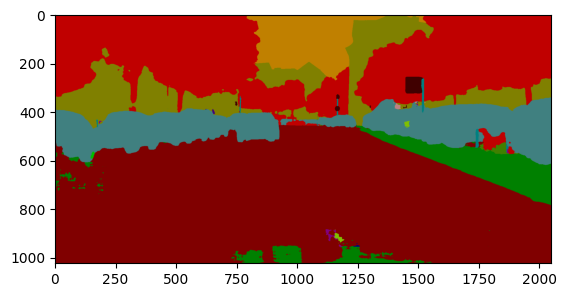

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('output/unet_results/pseudo_color_prediction/cityscapes4.png')

plt.figure("Image")
plt.imshow(img)
plt.show()

In [4]:
!ls configs/unet/

README.md			   unet_drive_128x128_40k.yml  unet_uterus.yml
unet_chasedb1_128x128_40k.yml	   unet_hrf_256x256_40k.yml
unet_cityscapes_1024x512_160k.yml  unet_stare_128x128_40k.yml


In [14]:
one_epoch = 200/4
print(one_epoch)
total_iters = one_epoch * 20
print(total_iters)

50.0
1000.0


In [17]:
custom_cfg = """
batch_size: 4
iters: 1000

train_dataset:
  type: Dataset
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train
  train_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/train.txt
  num_classes: 3
  transforms:
    - type: ResizeStepScaling
      min_scale_factor: 0.5
      max_scale_factor: 2.0
      scale_step_size: 0.25
    - type: RandomPaddingCrop
      crop_size: [1024, 512]
    - type: RandomHorizontalFlip
    - type: RandomDistort
      brightness_range: 0.4
      contrast_range: 0.4
      saturation_range: 0.4
    - type: Normalize
  mode: train

val_dataset:
  type: Dataset
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid
  val_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/val.txt
  num_classes: 3
  transforms:
    - type: Normalize
  mode: val

model:
  type: UNet
  num_classes: 3
  use_deconv: False
  pretrained: https://bj.bcebos.com/paddleseg/dygraph/cityscapes/unet_cityscapes_1024x512_160k/model.pdparams

optimizer:
  type: SGD
  momentum: 0.9
  weight_decay: 4.0e-5

lr_scheduler:
  type: PolynomialDecay
  learning_rate: 0.01
  end_lr: 0
  power: 0.9

loss:
  types:
    - type: CrossEntropyLoss
  coef: [1]
"""

with open('configs/unet/unet_uterus.yml', 'w') as f:
    f.write(custom_cfg)

In [18]:
# !python tools/train.py --help

# usage: train.py [-h] [--config CONFIG] [--device {cpu,gpu,xpu,npu,mlu}]
#                 [--save_dir SAVE_DIR] [--num_workers NUM_WORKERS] [--do_eval]
#                 [--use_vdl] [--use_ema] [--resume_model RESUME_MODEL]
#                 [--iters ITERS] [--batch_size BATCH_SIZE]
#                 [--learning_rate LEARNING_RATE]
#                 [--save_interval SAVE_INTERVAL] [--log_iters LOG_ITERS]
#                 [--keep_checkpoint_max KEEP_CHECKPOINT_MAX]
#                 [--early_stop_intervals EARLY_STOP_INTERVALS] [--seed SEED]
#                 [--precision {fp32,fp16}] [--amp_level {O1,O2}]
#                 [--profiler_options PROFILER_OPTIONS]
#                 [--data_format DATA_FORMAT] [--repeats REPEATS]
#                 [--opts OPTS [OPTS ...]] [--use_multilabel]
#                 [--to_static_training] [--output_op {argmax,softmax,none}]
#                 [--input_shape INPUT_SHAPE [INPUT_SHAPE ...]] [--for_fd]

In [19]:
!python tools/train.py \
       --config configs/unet/unet_uterus.yml \
       --device gpu \
       --num_workers 8 \
       --do_eval \
       --use_vdl \
       --save_interval 100 \
       --log_iters 5 \
       --keep_checkpoint_max 2 \
       --save_dir /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus

[2026/05/03 16:15:30] INFO: 
------------Environment Information-------------
platform: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Paddle compiled with cuda: True
NVCC: Build cuda_12.8.r12.8/compiler.35583870_0
cudnn: 90.8
GPUs used: 1
CUDA_VISIBLE_DEVICES: None
GPU: ['GPU 0: Tesla T4']
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PaddleSeg: 0.0.0.dev0
PaddlePaddle: 2.6.2
OpenCV: 4.13.0
------------------------------------------------
[2026/05/03 16:15:30] INFO: 
---------------Config Information---------------
batch_size: 4
iters: 1000
train_dataset:
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train
  mode: train
  num_classes: 3
  train_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/train.txt
  transforms:
  - max_scale_factor: 2.0
    min_scale_factor: 0.5
    scale_step_size: 0.25
    type: ResizeStepScaling
  - crop_size:
    - 1024
    - 512
    type: RandomPaddingCrop
  

In [3]:
!python tools/train.py \
       --config configs/unet/unet_uterus.yml \
       --device gpu \
       --num_workers 8 \
       --do_eval \
       --use_vdl \
       --resume_model /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/iter_1000 \
       --iters 2000 \
       --save_interval 100 \
       --log_iters 5 \
       --keep_checkpoint_max 2 \
       --save_dir /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus

[2026/05/03 17:16:12] INFO: 
------------Environment Information-------------
platform: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Paddle compiled with cuda: True
NVCC: Build cuda_12.8.r12.8/compiler.35583870_0
cudnn: 90.8
GPUs used: 1
CUDA_VISIBLE_DEVICES: None
GPU: ['GPU 0: Tesla T4']
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PaddleSeg: 0.0.0.dev0
PaddlePaddle: 2.6.2
OpenCV: 4.13.0
------------------------------------------------
[2026/05/03 17:16:12] INFO: 
---------------Config Information---------------
batch_size: 4
iters: 2000
train_dataset:
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train
  mode: train
  num_classes: 3
  train_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/train.txt
  transforms:
  - max_scale_factor: 2.0
    min_scale_factor: 0.5
    scale_step_size: 0.25
    type: ResizeStepScaling
  - crop_size:
    - 1024
    - 512
    type: RandomPaddingCrop
  

In [5]:
!python tools/train.py \
       --config configs/unet/unet_uterus.yml \
       --device gpu \
       --num_workers 8 \
       --do_eval \
       --use_vdl \
       --resume_model /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/iter_2000 \
       --iters 3000 \
       --save_interval 100 \
       --log_iters 5 \
       --keep_checkpoint_max 2 \
       --save_dir /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus

[2026/05/03 18:18:53] INFO: 
------------Environment Information-------------
platform: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Paddle compiled with cuda: True
NVCC: Build cuda_12.8.r12.8/compiler.35583870_0
cudnn: 90.8
GPUs used: 1
CUDA_VISIBLE_DEVICES: None
GPU: ['GPU 0: Tesla T4']
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PaddleSeg: 0.0.0.dev0
PaddlePaddle: 2.6.2
OpenCV: 4.13.0
------------------------------------------------
[2026/05/03 18:18:53] INFO: 
---------------Config Information---------------
batch_size: 4
iters: 3000
train_dataset:
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train
  mode: train
  num_classes: 3
  train_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/train.txt
  transforms:
  - max_scale_factor: 2.0
    min_scale_factor: 0.5
    scale_step_size: 0.25
    type: ResizeStepScaling
  - crop_size:
    - 1024
    - 512
    type: RandomPaddingCrop
  

In [4]:
# 0.8654

In [5]:
# !python tools/val.py --help

# usage: val.py [-h] [--config CONFIG] [--model_path MODEL_PATH]
#               [--num_workers NUM_WORKERS] [--device {cpu,gpu,xpu,npu,mlu}]
#               [--aug_eval] [--scales SCALES [SCALES ...]] [--flip_horizontal]
#               [--flip_vertical] [--is_slide] [--crop_size CROP_SIZE CROP_SIZE]
#               [--stride STRIDE STRIDE] [--data_format DATA_FORMAT]
#               [--auc_roc AUC_ROC] [--opts OPTS [OPTS ...]] [--use_multilabel]

In [6]:
!python tools/val.py \
       --config configs/unet/unet_uterus.yml \
       --model_path /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/best_model/model.pdparams \
       --device gpu \
       --num_workers 8

[2026/05/03 18:57:59] INFO: 
------------Environment Information-------------
platform: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Paddle compiled with cuda: True
NVCC: Build cuda_12.8.r12.8/compiler.35583870_0
cudnn: 90.8
GPUs used: 1
CUDA_VISIBLE_DEVICES: None
GPU: ['GPU 0: Tesla T4']
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PaddleSeg: 0.0.0.dev0
PaddlePaddle: 2.6.2
OpenCV: 4.13.0
------------------------------------------------
[2026/05/03 18:57:59] INFO: 
---------------Config Information---------------
batch_size: 4
iters: 1000
train_dataset:
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train
  mode: train
  num_classes: 3
  train_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/train.txt
  transforms:
  - max_scale_factor: 2.0
    min_scale_factor: 0.5
    scale_step_size: 0.25
    type: ResizeStepScaling
  - crop_size:
    - 1024
    - 512
    type: RandomPaddingCrop
  

In [7]:
!python tools/predict.py \
       --config configs/unet/unet_uterus.yml \
       --model_path /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/best_model/model.pdparams \
       --device gpu \
       --image_path /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images \
       --save_dir /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/infer_images/

[2026/05/03 18:59:29] INFO: 
------------Environment Information-------------
platform: Linux-6.6.113+-x86_64-with-glibc2.35
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Paddle compiled with cuda: True
NVCC: Build cuda_12.8.r12.8/compiler.35583870_0
cudnn: 90.8
GPUs used: 1
CUDA_VISIBLE_DEVICES: None
GPU: ['GPU 0: Tesla T4']
GCC: gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
PaddleSeg: 0.0.0.dev0
PaddlePaddle: 2.6.2
OpenCV: 4.13.0
------------------------------------------------
[2026/05/03 18:59:29] INFO: 
---------------Config Information---------------
batch_size: 4
iters: 1000
train_dataset:
  dataset_root: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train
  mode: train
  num_classes: 3
  train_path: /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/train/train.txt
  transforms:
  - max_scale_factor: 2.0
    min_scale_factor: 0.5
    scale_step_size: 0.25
    type: ResizeStepScaling
  - crop_size:
    - 1024
    - 512
    type: RandomPaddingCrop
  

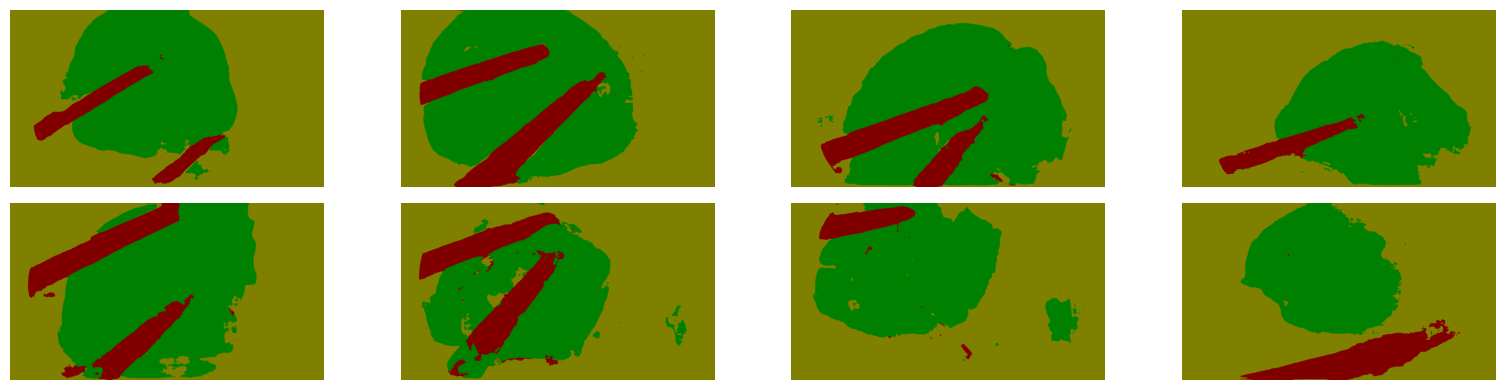

In [8]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import cv2
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/infer_images/pseudo_color_prediction"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
!python tools/export.py \
       --config configs/unet/unet_uterus.yml \
       --model_path /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/best_model/model.pdparams \
       --save_dir output_inference/unet_uterus

[2026/05/03 19:01:14] INFO: Use the following config to build model
model:
  num_classes: 3
  pretrained: https://bj.bcebos.com/paddleseg/dygraph/cityscapes/unet_cityscapes_1024x512_160k/model.pdparams
  type: UNet
  use_deconv: false
W0503 19:01:14.014040 56234 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0503 19:01:14.015028 56234 gpu_resources.cc:164] device: 0, cuDNN Version: 9.8.
[2026/05/03 19:01:14] INFO: Loading pretrained model from https://bj.bcebos.com/paddleseg/dygraph/cityscapes/unet_cityscapes_1024x512_160k/model.pdparams
[2026/05/03 19:01:14] WARNING: [SKIP] Shape of pretrained params cls.weight doesn't match.(Pretrained: [19, 64, 3, 3], Actual: [3, 64, 3, 3])
[2026/05/03 19:01:14] WARNING: [SKIP] Shape of pretrained params cls.bias doesn't match.(Pretrained: [19], Actual: [3])
[2026/05/03 19:01:14] WARNING: [SKIP] Shape of pretrained params conv.weight doesn't match.(Pretrained: [19, 64, 

In [10]:
def normalize(img, mean, std):
    img = img / 255.0
    mean = np.array(mean)[np.newaxis, np.newaxis, :]
    std = np.array(std)[np.newaxis, np.newaxis, :]
    img -= mean
    img /= std
    return img

def preprocess(img, img_size):
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
    img = cv2.resize(img, (img_size[0], img_size[1]))
    img = img[:, :, ::-1].astype('float32')  # bgr -> rgb
    img = normalize(img, mean, std)
    img = img.transpose((2, 0, 1))  # hwc -> chw
    return img[np.newaxis, :]

In [11]:
import paddle
paddle.utils.run_check()

Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 GPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.


In [12]:
import paddle.inference as paddle_infer
import cv2
import numpy as np

config = paddle_infer.Config("output_inference/unet_uterus/model.pdmodel", "output_inference/unet_uterus/model.pdiparams")
config.enable_use_gpu(100, 0)
predictor = paddle_infer.create_predictor(config)

img = cv2.imread("/content/gdrive/MyDrive/PaddleDet-Models/datasets/sispanseg/valid/images/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg")
im_size = [1024, 512]
data = preprocess(img, im_size)

input_names = predictor.get_input_names()
input_tensor = predictor.get_input_handle(input_names[0])
input_tensor.reshape(img.shape)
input_tensor.copy_from_cpu(data.copy())

predictor.run()
output_names = predictor.get_output_names()
output_tensor = predictor.get_output_handle(output_names[0])
output_data = output_tensor.copy_to_cpu()
print(output_data.shape)

(1, 512, 1024)


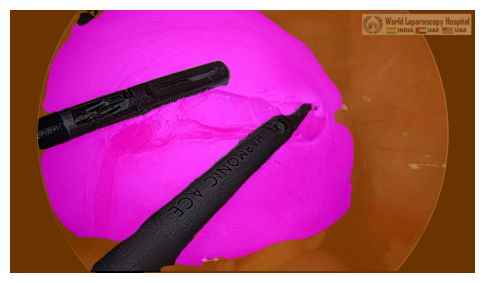

In [14]:
CATEGORY_COLORS = {
    0: [0, 0, 0],           # Things (Black)
    1: [255, 0, 255],       # Uterus (Magenta)
    2: [0, 75, 150],        # BG (Brown)
}
orig_h, orig_w = img.shape[:2]

# 1. Create a color palette array (fast lookup)
palette_map = np.zeros((256, 3), dtype=np.uint8)
for i, color in CATEGORY_COLORS.items():
    palette_map[i] = color

# 2. Apply the colors in one vectorized step
mask = output_data[0].squeeze().astype(np.uint8)
color_mask = palette_map[mask] # Instant mapping

color_mask = cv2.resize(color_mask, (orig_w, orig_h))

# 3. Create a fast overlay
overlay = cv2.addWeighted(img, 0.3, color_mask, 0.7, 0)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

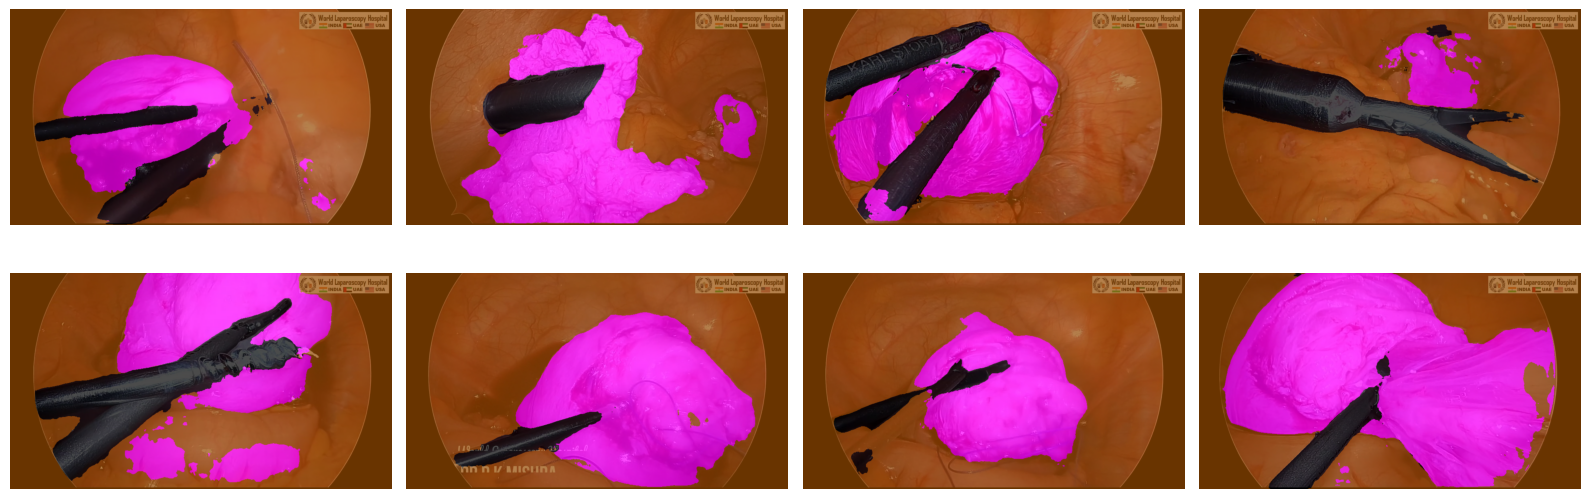

In [15]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/datasets/sispanseg/valid/images/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    data = preprocess(img, im_size)

    input_names = predictor.get_input_names()
    input_tensor = predictor.get_input_handle(input_names[0])
    input_tensor.reshape(img.shape)
    input_tensor.copy_from_cpu(data.copy())

    predictor.run()
    output_names = predictor.get_output_names()
    output_tensor = predictor.get_output_handle(output_names[0])
    output_data = output_tensor.copy_to_cpu()

    orig_h, orig_w = img.shape[:2]

    mask = output_data[0].squeeze().astype(np.uint8)
    color_mask = palette_map[mask] # Instant mapping

    color_mask = cv2.resize(color_mask, (orig_w, orig_h))
    overlay = cv2.addWeighted(img, 0.3, color_mask, 0.7, 0)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
!pip install onnx onnxscript paddle2onnx==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.9 MB/s eta 0:00:00


In [30]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 MB 4.5 MB/s eta 0:00:00


In [16]:
!paddle2onnx --model_dir=./output_inference/unet_uterus/ \
            --model_filename model.pdmodel  \
            --params_filename model.pdiparams \
            --opset_version 16 \
            --save_file /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/unet_uterus.onnx

[Paddle2ONNX] Start to parse PaddlePaddle model...
[Paddle2ONNX] Model file path: ./output_inference/unet_uterus/model.pdmodel
[Paddle2ONNX] Paramters file path: ./output_inference/unet_uterus/model.pdiparams
[Paddle2ONNX] Start to parsing Paddle model...
[Paddle2ONNX] Use opset_version = 16 for ONNX export.
[Paddle2ONNX] PaddlePaddle model is exported as ONNX format now.
2026-05-03 19:02:58 [INFO]	===============Make PaddlePaddle Better!================
2026-05-03 19:02:58 [INFO]	A little survey: https://iwenjuan.baidu.com/?code=r8hu2s


In [20]:
%ls /content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/

best_model/    unet_uterus.onnx           vdlrecords.1777832218.log
infer_images/  vdlrecords.1777824934.log  vdlrecords.1777832334.log
iter_2900/     vdlrecords.1777828499.log
iter_3000/     vdlrecords.1777828573.log


In [21]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "/content/gdrive/MyDrive/PaddleDet-Models/datasets/sispanseg/valid/images/Laparoscopic-Myomectomy-with-Baseball-Suturing-22-_jpg.rf.04929e16d4ace3507c937c4e1ce8a333.jpg"

mean = np.array([0.5, 0.5, 0.5], dtype=np.float32)
std = np.array([0.5, 0.5, 0.5], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (1024, 512))
img_input = img_resized[:, :, ::-1].astype(np.float32) / 255.0
img_input = (img_input - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("/content/gdrive/MyDrive/PaddleDet-Models/PaddleSeg/paddleseg-outputs/unet_uterus/unet_uterus.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# Inspect inputs to confirm names and shapes (for debugging)
input_names = [inp.name for inp in session.get_inputs()]
print("Expected input names from ONNX model:", input_names)
print("Output:", [o.shape for o in outputs])

Expected input names from ONNX model: ['x']
Output: [(1, 512, 1024)]


In [22]:
print(outputs[0])

[[[2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  ...
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]
  [2 2 2 ... 2 2 2]]]


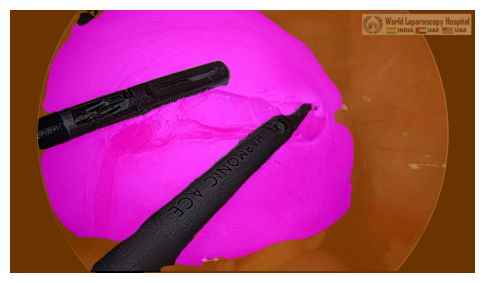

In [26]:
CATEGORY_COLORS = {
    0: [0, 0, 0],           # Things (Black)
    1: [255, 0, 255],       # Uterus (Magenta)
    2: [0, 75, 150],        # BG (Brown)
}
orig_h, orig_w = img.shape[:2]

# 1. Create a color palette array (fast lookup)
palette_map = np.zeros((256, 3), dtype=np.uint8)
for i, color in CATEGORY_COLORS.items():
    palette_map[i] = color

# 2. Apply the colors in one vectorized step
mask = outputs[0].squeeze().astype(np.uint8) # outputs[0] is already the class map, argmax is not needed
color_mask = palette_map[mask] # Instant mapping

color_mask = cv2.resize(color_mask, (orig_w, orig_h))

# 3. Create a fast overlay
overlay = cv2.addWeighted(img, 0.3, color_mask, 0.7, 0)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

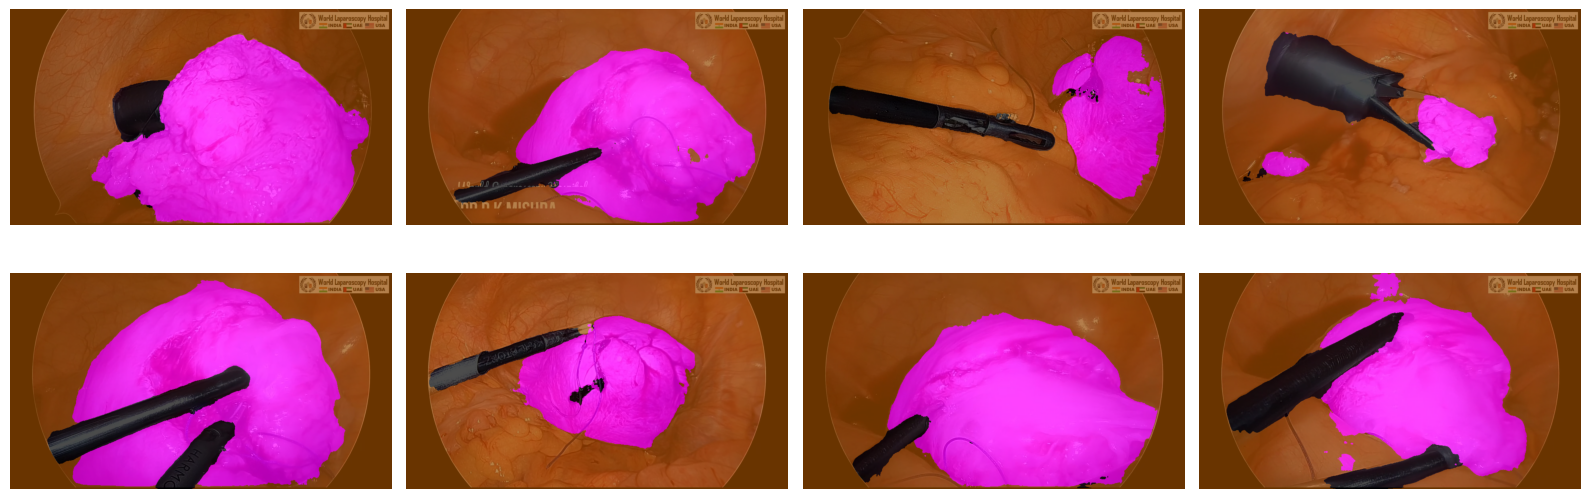

In [27]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/datasets/sispanseg/valid/images/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 3 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (1024, 512))
    img_input = img_resized[:, :, ::-1].astype(np.float32) / 255.0
    img_input = (img_input - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    orig_h, orig_w = img.shape[:2]

    mask = outputs[0].squeeze().astype(np.uint8)
    color_mask = palette_map[mask] # Instant mapping

    color_mask = cv2.resize(color_mask, (orig_w, orig_h))
    overlay = cv2.addWeighted(img, 0.3, color_mask, 0.7, 0)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()